# Step by Step Guide to run models on Raspberry Pi Zero 2W

- Import models
- Create a Virtual environment
- Activate it
- pip install jupyter
- run jupyter notebook --ip=[YOUR IP ADDREES] --no-browser
- Open on Browser or VSCode with link

# Checando conexão do Microfone:

In [1]:
!pwd

/home/rolds/Documents


In [2]:
!arecord -l

**** List of CAPTURE Hardware Devices ****
card 0: SoloCast [HyperX SoloCast], device 0: USB Audio [USB Audio]
  Subdevices: 1/1
  Subdevice #0: subdevice #0


In [3]:
!ls

KWS  model_mfcc_fp16.tflite  output.wav


# Instalações:

In [4]:
!sudo apt-get install portaudio19-dev python3-dev -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.2).
python3-dev is already the newest version (3.11.2-1+b1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [5]:
!pip install pyaudio

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [6]:
import pyaudio

index = 0

p = pyaudio.PyAudio()
info = p.get_host_api_info_by_index(index)
numdevices = info.get('deviceCount')

print("Dispositivos de áudio encontrados:")
for i in range(0, numdevices):
    device_info = p.get_device_info_by_host_api_device_index(index, i)
    if device_info.get('maxInputChannels') > 0:
        print(f"  Índice de Entrada {i}: {device_info.get('name')}")

p.terminate()

Dispositivos de áudio encontrados:
  Índice de Entrada 0: HyperX SoloCast: USB Audio (hw:0,0)
  Índice de Entrada 1: sysdefault
  Índice de Entrada 2: spdif
  Índice de Entrada 3: default


ALSA lib pcm_dmix.c:999:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib confmisc.c:1369:(snd_func_refer) Unable to find definition 'cards.0.pcm.hdmi.0:CARD=0,AES0=4,AES1=130,AES2=0,AES3=2'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM hdmi
ALSA lib confmisc.c:1369:(snd_func_refer) Unable to find definition 'cards.0.pcm.hdmi.0:CARD=0,AES0=4,AES1=130,AES2=0,AES3=2'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:26

In [7]:
!pip install numpy==1.25.2

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [8]:
!pip install scipy

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [9]:
!pip install gpiozero

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [10]:
!pip install tflite-runtime

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [11]:
!pip install librosa

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [21]:
!pip install matplotlib

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 1.4 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 1.7 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


# Teste de Microfone Offline:

In [10]:
import pyaudio
import wave
import numpy as np
print(np.__version__)
from scipy.signal import resample_poly

1.25.2


In [11]:
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000
TARGET_RATE = 16000

CHUNK = 1024
RECORD_SECONDS = 10

DEVICE_INDEX = 0   # replace this with your detected USB mic's index
WAVE_OUTPUT_FILENAME = "output.wav"

In [12]:
audio = pyaudio.PyAudio()

stream = audio.open(
    format=FORMAT,
    channels=CHANNELS,
    rate=RATE,
    input=True,
    input_device_index=DEVICE_INDEX,
    frames_per_buffer=CHUNK
)

In [13]:
print("Recording...")

frames = []

for i in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
    data = stream.read(CHUNK, exception_on_overflow=False)
    frames.append(data)

print("Finished recording.")

stream.stop_stream()
stream.close()
audio.terminate()

audio_data = np.frombuffer(b''.join(frames), dtype=np.int16)

# Calcula os fatores para a reamostragem (de 48k para 16k é 1/3)
resampled_data = resample_poly(audio_data, TARGET_RATE, RATE)

# Converte de volta para int16
resampled_data = resampled_data.astype(np.int16)

wf = wave.open(WAVE_OUTPUT_FILENAME, 'wb')

# Define os parâmetros do ÁUDIO REAMOSTRADO
wf.setnchannels(CHANNELS)
wf.setsampwidth(audio.get_sample_size(FORMAT))
wf.setframerate(TARGET_RATE) # <-- MUDANÇA 1: Usar a taxa de amostragem de destino

# Escreve os dados REAMOSTRADOS no arquivo
# .tobytes() converte o array NumPy de volta para bytes
wf.writeframes(resampled_data.tobytes()) # <-- MUDANÇA 2: Usar os dados reamostrados

wf.close()

Recording...
Finished recording.


In [14]:
!ls

KWS  output.wav


In [15]:
import IPython.display as ipd
ipd.Audio("output.wav")

# Teste Modelo:

In [1]:
!ls

KWS  model_mfcc_fp16.tflite  output.wav


In [2]:
import time
import numpy as np
import pyaudio
import librosa
import tflite_runtime.interpreter as tflite
from collections import deque
from scipy.signal import resample_poly
from gpiozero import LED
import wave

/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [3]:
LED_GO = LED(26)
LED_STOP = LED(6)

LED_ON = LED(27)
LED_OFF = LED(4)

LED_NO = LED(5)

/home/rolds/Documents/KWS/lib/python3.11/site-packages/gpiozero/devices.py:300: PinFactoryFallback: Falling back from lgpio: No module named 'lgpio'
  warnings.warn(
/home/rolds/Documents/KWS/lib/python3.11/site-packages/gpiozero/devices.py:300: PinFactoryFallback: Falling back from rpigpio: No module named 'RPi'
  warnings.warn(
/home/rolds/Documents/KWS/lib/python3.11/site-packages/gpiozero/devices.py:300: PinFactoryFallback: Falling back from pigpio: No module named 'pigpio'
  warnings.warn(
/home/rolds/Documents/KWS/lib/python3.11/site-packages/gpiozero/devices.py:297: NativePinFactoryFallback: Falling back to the experimental pin factory NativeFactory because no other pin factory could be loaded. For best results, install RPi.GPIO or pigpio. See https://gpiozero.readthedocs.io/en/stable/api_pins.html for more information.
  warnings.warn(NativePinFactoryFallback(native_fallback_message))


In [4]:
LED_GO.off()
LED_STOP.off()
LED_ON.off()
LED_OFF.off()
LED_NO.off()

In [5]:
# Teste de LEDs:

LED_GO.on()
LED_STOP.on()
LED_ON.on()
LED_OFF.on()
LED_NO.on()

time.sleep(3)  # Mantém os LEDs acesos por 3 segundos

LED_GO.off()
LED_STOP.off()
LED_ON.off()
LED_OFF.off()
LED_NO.off()

Copie o modelo para o diretório atual

In [6]:
!ls

KWS  model_mfcc_fp16.tflite  output.wav


In [7]:
CLASS_NAMES = ['_silence_', '_unknown_', 'go', 'no', 'off', 'on', 'stop']

MODEL_PATH = "./model_mfcc_fp16.tflite"

In [8]:
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000
TARGET_RATE = 16000

RECORD_SECONDS = 1
CHUNK = RATE * RECORD_SECONDS

DEVICE_INDEX = 0

In [9]:
print("Carregando modelo TFLite...")

interpreter = tflite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Modelo carregado com sucesso.")
print("Input shape:", input_details[0]['shape'])

Carregando modelo TFLite...
Modelo carregado com sucesso.
Input shape: [ 1 61 40  1]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [11]:
N_FFT = 512
FRAME_STEP = 256
N_MELS = 128
N_MFCCS = 40
F_MIN = 20
F_MAX = TARGET_RATE / 2

In [10]:
def preprocess_audio(audio_data):
    """
    Recebe 1 segundo de áudio, extrai os MFCCs e formata
    para a entrada do modelo.
    """
    mfccs = librosa.feature.mfcc(
        y=audio_data,
        sr=TARGET_RATE,
        n_mfcc=N_MFCCS,
        n_fft=N_FFT,
        hop_length=FRAME_STEP,
        win_length=N_FFT,
        n_mels=N_MELS,
        fmin=F_MIN,
        fmax=F_MAX,
        center=False
    )
    
    mfccs = mfccs.T
    mfccs = np.expand_dims(mfccs, axis=-1)
    mfccs = np.expand_dims(mfccs, axis=0)
    
    return mfccs.astype(np.float32)

In [92]:
audio = pyaudio.PyAudio()

WAVE_OUTPUT_FILENAME = "output.wav"

stream = audio.open(
    format=FORMAT,
    channels=CHANNELS,
    rate=RATE,
    input=True,
    input_device_index=DEVICE_INDEX,
    frames_per_buffer=CHUNK
)

print("Recording...")

frames = []

for i in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
    data = stream.read(CHUNK, exception_on_overflow=False)
    frames.append(data)

print("Finished recording.")

stream.stop_stream()
stream.close()
audio.terminate()

audio_data = np.frombuffer(b''.join(frames), dtype=np.int16)

resampled_data = resample_poly(audio_data, TARGET_RATE, RATE)

resampled_data = resampled_data.astype(np.int16)

wf = wave.open(WAVE_OUTPUT_FILENAME, 'wb')
wf.setnchannels(CHANNELS)
wf.setsampwidth(audio.get_sample_size(FORMAT))
wf.setframerate(TARGET_RATE)
wf.writeframes(resampled_data.tobytes())

wf.close()

ALSA lib pcm_dmix.c:999:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib confmisc.c:1369:(snd_func_refer) Unable to find definition 'cards.0.pcm.hdmi.0:CARD=0,AES0=4,AES1=130,AES2=0,AES3=2'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM hdmi
ALSA lib confmisc.c:1369:(snd_func_refer) Unable to find definition 'cards.0.pcm.hdmi.0:CARD=0,AES0=4,AES1=130,AES2=0,AES3=2'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:26

Recording...
Finished recording.


In [93]:
import IPython.display as ipd
ipd.Audio("output.wav")

In [94]:
resampled_data = resampled_data.astype(np.float32) / 32768.0

In [95]:
max(resampled_data)

0.25268555

In [96]:
min(resampled_data)

-0.29156494

In [97]:
preprocessed_data = preprocess_audio(resampled_data)

In [98]:
preprocessed_data.shape

(1, 61, 40, 1)

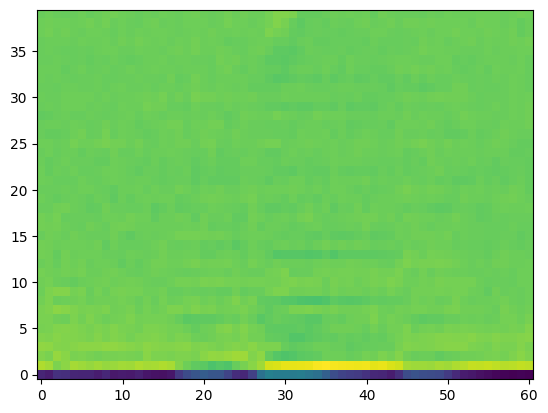

In [99]:
import matplotlib.pyplot as plt

plt.imshow(preprocessed_data[0, :, :, 0].T, aspect='auto', origin='lower')

In [ ]:
print("Carregando modelo TFLite...")

interpreter = tflite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Modelo carregado com sucesso.")
print("Input shape:", input_details[0]['shape'])

# Executa a inferência
interpreter.set_tensor(input_details[0]['index'], preprocessed_data)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
prediction_index = np.argmax(output_data[0])
predicted_class = CLASS_NAMES[prediction_index]
confidence = np.max(output_data[0])

print(f"DETECÇÃO: {predicted_class} (Confiança: {confidence:.2f})")

DETECÇÃO: stop (Confiança: 1.00)


# Teste Real-Time:

In [1]:
import time
import numpy as np
import pyaudio
import librosa
import tflite_runtime.interpreter as tflite
from collections import deque
from scipy.signal import resample_poly
from gpiozero import LED

LED_GO = LED(26)
LED_STOP = LED(6)
LED_ON = LED(27)
LED_OFF = LED(4)
LED_NO = LED(5)

def preprocess_audio(audio_data):
    """
    Recebe 1 segundo de áudio, extrai os MFCCs e formata
    para a entrada do modelo.
    """
    mfccs = librosa.feature.mfcc(
        y=audio_data,
        sr=TARGET_RATE,
        n_mfcc=N_MFCCS,
        n_fft=N_FFT,
        hop_length=FRAME_STEP,
        win_length=N_FFT,
        n_mels=N_MELS,
        fmin=F_MIN,
        fmax=F_MAX,
        center=False
    )
    
    mfccs = mfccs.T
    mfccs = np.expand_dims(mfccs, axis=-1)
    mfccs = np.expand_dims(mfccs, axis=0)
    
    return mfccs.astype(np.float32)

CLASS_NAMES = ['_silence_', '_unknown_', 'go', 'no', 'off', 'on', 'stop']
MODEL_PATH = "./model_mfcc_fp16.tflite"

FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000
TARGET_RATE = 16000
DEVICE_INDEX = 0

WINDOW_DURATION_S = 1.0
STEP_DURATION_S = 0.5

CHUNK = int(RATE * STEP_DURATION_S)

BUFFER_MAX_LEN = int(WINDOW_DURATION_S / STEP_DURATION_S)

N_FFT = 512
FRAME_STEP = 256
N_MELS = 128
N_MFCCS = 40
F_MIN = 20
F_MAX = TARGET_RATE / 2

audio = pyaudio.PyAudio()

stream = audio.open(
    format=FORMAT,
    channels=CHANNELS,
    rate=RATE,
    input=True,
    input_device_index=DEVICE_INDEX,
    frames_per_buffer=CHUNK
)

print("Carregando modelo TFLite...")

interpreter = tflite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Modelo carregado com sucesso.")
print("Input shape:", input_details[0]['shape'])

print("\nIniciando inferência com janela deslizante... (Pressione Ctrl+C para parar)")

audio_buffer = deque(maxlen=BUFFER_MAX_LEN)

LAST_DETECTION_TIME = 0
COOLDOWN_S = 1.5

try:
    while True:
        # 1. Ler 0.5s de áudio (CHUNK)
        data = stream.read(CHUNK, exception_on_overflow=False)
        
        # 2. Adicionar ao buffer
        audio_buffer.append(data)

        # 3. Se o buffer ainda não estiver cheio (primeiro 1s),
        # pular a inferência e continuar enchendo.
        if len(audio_buffer) < BUFFER_MAX_LEN:
            continue
            
        # 4. Concatenar os 2 blocos de 0.5s para formar 1.0s de áudio
        full_buffer_bytes = b''.join(audio_buffer)
        
        # 5. Converter buffer para numpy (int16) - 1.0s a 48kHz
        audio_data = np.frombuffer(full_buffer_bytes, dtype=np.int16)

        # 6. Resample de 48kHz para 16kHz
        resampled_data = resample_poly(audio_data, TARGET_RATE, RATE)

        # 7. Normalizar para float32
        resampled_data_float = resampled_data.astype(np.float32) / 32768.0

        # 8. Pré-processar (MFCCs)
        preprocessed_data = preprocess_audio(resampled_data_float)
        
        # 9. Executar a inferência
        interpreter.set_tensor(input_details[0]['index'], preprocessed_data)
        interpreter.invoke()

        # 10. Obter resultados
        output_data = interpreter.get_tensor(output_details[0]['index'])
        prediction_index = np.argmax(output_data[0])
        predicted_class = CLASS_NAMES[prediction_index]
        confidence = np.max(output_data[0])

        # 11. Aplicar "Cooldown" para evitar detecções duplicadas
        current_time = time.time()
        
        if predicted_class not in ['_silence_', '_unknown_'] and (current_time - LAST_DETECTION_TIME > COOLDOWN_S):
            print(f"DETECÇÃO: {predicted_class} (Confiança: {confidence:.2f})")

            # Acionar LEDs conforme a detecção
            if predicted_class == 'go':
                LED_GO.on()
                time.sleep(1)
                LED_GO.off()
            elif predicted_class == 'stop':
                LED_STOP.on()
                time.sleep(1)
                LED_STOP.off()
            elif predicted_class == 'on':
                LED_ON.on()
                time.sleep(1)
                LED_ON.off()
            elif predicted_class == 'off':
                LED_OFF.on()
                time.sleep(1)
                LED_OFF.off()
            elif predicted_class == 'no':
                LED_NO.on()
                time.sleep(1)
                LED_NO.off()
                
            LAST_DETECTION_TIME = current_time # Reinicia o cooldown

except KeyboardInterrupt:
    print("\nParando a gravação.")

finally:
    print("Liberando recursos...")
    stream.stop_stream()
    stream.close()
    audio.terminate()
    print("Pronto.")

/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/rolds/Documents/KWS/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/rolds/Documents/KWS/lib/python3.11/site-packages/gpiozero/devices.py:300: PinFactory

Carregando modelo TFLite...
Modelo carregado com sucesso.
Input shape: [ 1 61 40  1]

Iniciando inferência com janela deslizante... (Pressione Ctrl+C para parar)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: stop (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: off (Confiança: 1.00)
DETECÇÃO: stop (Confiança: 1.00)
DETECÇÃO: stop (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)
DETECÇÃO: go (Confiança: 1.00)

Parando a gravação.
Liberando recursos...
Pronto.
